In [1]:
# Cell 1 - imports and loading preprocessed data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GRU, LSTM, Dense, Dropout, Input,
    LayerNormalization, Multiply, Softmax, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.regularizers import l2
import mlflow
import mlflow.tensorflow
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# paths
DATA_PROCESSED = Path('../data/processed')
MODELS_DIR     = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

# load preprocessed sequences
X_train = np.load(DATA_PROCESSED / 'X_train.npy')
y_train = np.load(DATA_PROCESSED / 'y_train.npy')
X_test  = np.load(DATA_PROCESSED / 'X_test.npy')
y_test  = np.load(DATA_PROCESSED / 'y_test.npy')

# load config
with open(MODELS_DIR / 'model_config.pkl', 'rb') as f:
    config = pickle.load(f)

SEQUENCE_LENGTH = config['sequence_length']
N_FEATURES      = config['n_features']
RUL_CAP         = config['rul_cap']

print("data loaded:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")
print(f"\nmodel input: ({SEQUENCE_LENGTH} timesteps, {N_FEATURES} features)")

data loaded:
  X_train: (17731, 30, 14)
  y_train: (17731,)
  X_test:  (100, 30, 14)
  y_test:  (100,)

model input: (30 timesteps, 14 features)


In [3]:
# Cell 2 - flexible model architecture with custom attention layer
# wrapping attention in a proper Keras layer — required in Keras 3

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GRU, LSTM, Dense, Dropout, Input, 
    LayerNormalization, Layer
)
from tensorflow.keras.regularizers import l2

class ScaledDotProductAttention(Layer):
    """
    scaled dot-product attention as a proper Keras layer
    learns which timesteps to focus on when predicting RUL
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.layer_norm = LayerNormalization()

    def call(self, x):
        # x shape: (batch, timesteps, units)
        d_k    = tf.cast(tf.shape(x)[-1], tf.float32)
        scale  = tf.math.sqrt(d_k)
        scores  = tf.matmul(x, x, transpose_b=True) / scale
        weights = tf.nn.softmax(scores, axis=-1)
        context = tf.matmul(weights, x)
        # residual connection + layer norm
        return self.layer_norm(x + context)

def build_model(sequence_length, n_features,
                n_gru_layers=4,
                gru_units=64,
                lstm_units=64,
                dropout_rate=0.2,
                l2_reg=0.001,
                reverse_order=False):
    """
    flexible GRU-LSTM hybrid with scaled dot-product attention
    reverse_order=True puts LSTM before GRU — testing order impact
    """
    inputs = Input(shape=(sequence_length, n_features))
    x = inputs

    if not reverse_order:
        # standard order: GRU first, then LSTM
        for i in range(n_gru_layers):
            x = GRU(gru_units, return_sequences=True,
                    kernel_regularizer=l2(l2_reg),
                    name=f'gru_{i+1}')(x)
            x = Dropout(dropout_rate, name=f'dropout_gru_{i+1}')(x)

        # LSTM — capturing longer term degradation trends
        x = LSTM(lstm_units, return_sequences=True,
                 kernel_regularizer=l2(l2_reg),
                 name='lstm_1')(x)
        x = Dropout(dropout_rate, name='dropout_lstm')(x)

    else:
        # reversed: LSTM first, then GRU — testing order impact
        x = LSTM(lstm_units, return_sequences=True,
                 kernel_regularizer=l2(l2_reg),
                 name='lstm_1')(x)
        x = Dropout(dropout_rate, name='dropout_lstm')(x)

        for i in range(n_gru_layers):
            x = GRU(gru_units, return_sequences=True,
                    kernel_regularizer=l2(l2_reg),
                    name=f'gru_{i+1}')(x)
            x = Dropout(dropout_rate, name=f'dropout_gru_{i+1}')(x)

    # attention — wrapped in proper Keras layer
    x = ScaledDotProductAttention(name='attention')(x)

    # take the last timestep
    x = x[:, -1, :]

    # output head
    x = Dense(32, activation='swish', name='dense_1')(x)
    x = Dropout(dropout_rate, name='dropout_output')(x)
    outputs = Dense(1, activation='relu', name='rul_output')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# quick test — dissertation baseline
test_model = build_model(
    sequence_length=SEQUENCE_LENGTH,
    n_features=N_FEATURES,
    n_gru_layers=4,
    gru_units=64,
    lstm_units=64,
    dropout_rate=0.2
)
test_model.summary()
print(f"\ntotal parameters: {test_model.count_params():,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 64)         │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_gru_1 (Dropout)         │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 30, 64)         │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_gru_2 (Dropout)         │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 30, 64)         │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_gru_3 (Dropout)         │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 30, 64)         │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_gru_4 (Dropout)         │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_lstm (Dropout)          │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention                       │ (None, 30, 64)         │           128 │
│ (ScaledDotProductAttention)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_output (Dropout)        │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_output (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,505 (490.25 KB)

 Trainable params: 125,505 (490.25 KB)

 Non-trainable params: 0 (0.00 B)


total parameters: 125,505


In [4]:
# Cell 3 - training function with MLflow logging
# wrapping everything in one function so we can call it for each experiment

from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('jet_engine_rul')

def train_and_log(run_name, n_gru_layers, gru_units, lstm_units,
                  dropout_rate, learning_rate=0.001, l2_reg=0.001,
                  epochs=50, batch_size=256, reverse_order=False):
    
    with mlflow.start_run(run_name=run_name):
        
        # log all hyperparameters
        mlflow.log_params({
            'n_gru_layers':    n_gru_layers,
            'gru_units':       gru_units,
            'lstm_units':      lstm_units,
            'dropout_rate':    dropout_rate,
            'learning_rate':   learning_rate,
            'l2_reg':          l2_reg,
            'batch_size':      batch_size,
            'sequence_length': SEQUENCE_LENGTH,
            'rul_cap':         RUL_CAP,
            'reverse_order':   reverse_order
        })
        
        # build model
        model = build_model(
            sequence_length=SEQUENCE_LENGTH,
            n_features=N_FEATURES,
            n_gru_layers=n_gru_layers,
            gru_units=gru_units,
            lstm_units=lstm_units,
            dropout_rate=dropout_rate,
            l2_reg=l2_reg,
            reverse_order=reverse_order
        )
        
        model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='mse',
            metrics=['mae']
        )
        
        # callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_loss', patience=10,
                restore_best_weights=True, verbose=0
            ),
            ReduceLROnPlateau(
                monitor='val_loss', factor=0.5,
                patience=5, min_lr=1e-6, verbose=0
            )
        ]
        
        # train
        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        
        # evaluate on test set
        y_pred = model.predict(X_test, verbose=0).flatten()
        
        # cap predictions at RUL_CAP
        y_pred_capped = np.clip(y_pred, 0, RUL_CAP)
        y_test_capped = np.clip(y_test, 0, RUL_CAP)
        
        rmse = math.sqrt(mean_squared_error(y_test_capped, y_pred_capped))
        mae  = mean_absolute_error(y_test_capped, y_pred_capped)
        r2   = 1 - (np.sum((y_test_capped - y_pred_capped)**2) / 
                    np.sum((y_test_capped - np.mean(y_test_capped))**2))
        
        best_epoch = len(history.history['loss'])
        
        # log metrics
        mlflow.log_metrics({
            'test_rmse':   rmse,
            'test_mae':    mae,
            'test_r2':     r2,
            'best_epoch':  best_epoch,
            'final_val_loss': min(history.history['val_loss'])
        })
        
        print(f"\n{'='*50}")
        print(f"Run: {run_name}")
        print(f"  RMSE:       {rmse:.4f}")
        print(f"  MAE:        {mae:.4f}")
        print(f"  R²:         {r2:.4f}")
        print(f"  Best epoch: {best_epoch}")
        print(f"{'='*50}\n")
        
        return model, history, rmse, mae

print("training function ready")
print("MLflow tracking: sqlite:///mlflow.db")
print("experiment: jet_engine_rul")

2026/04/18 19:51:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/18 19:51:08 INFO mlflow.store.db.utils: Updating database tables
2026/04/18 19:51:11 INFO mlflow.tracking.fluent: Experiment with name 'jet_engine_rul' does not exist. Creating a new experiment.


training function ready
MLflow tracking: sqlite:///mlflow.db
experiment: jet_engine_rul


In [5]:
# Cell 4 - running the experiment grid
# 9 runs — tracking everything in MLflow
# this will take 20-30 minutes total

results = []

# Run 1: small model — baseline to see if complexity is even needed
model_1, hist_1, rmse_1, mae_1 = train_and_log(
    run_name='run_01_2gru32_lstm32',
    n_gru_layers=2, gru_units=32, lstm_units=32,
    dropout_rate=0.2
)
results.append({'run': 'run_01', 'config': '2GRU(32)+LSTM(32)', 
                'dropout': 0.2, 'rmse': rmse_1, 'mae': mae_1})

# Run 2: bigger GRU units, same structure
model_2, hist_2, rmse_2, mae_2 = train_and_log(
    run_name='run_02_2gru64_lstm32',
    n_gru_layers=2, gru_units=64, lstm_units=32,
    dropout_rate=0.2
)
results.append({'run': 'run_02', 'config': '2GRU(64)+LSTM(32)', 
                'dropout': 0.2, 'rmse': rmse_2, 'mae': mae_2})

# Run 3: adding a GRU layer
model_3, hist_3, rmse_3, mae_3 = train_and_log(
    run_name='run_03_3gru64_lstm32',
    n_gru_layers=3, gru_units=64, lstm_units=32,
    dropout_rate=0.2
)
results.append({'run': 'run_03', 'config': '3GRU(64)+LSTM(32)', 
                'dropout': 0.2, 'rmse': rmse_3, 'mae': mae_3})

# Run 4: bigger LSTM
model_4, hist_4, rmse_4, mae_4 = train_and_log(
    run_name='run_04_3gru64_lstm64',
    n_gru_layers=3, gru_units=64, lstm_units=64,
    dropout_rate=0.2
)
results.append({'run': 'run_04', 'config': '3GRU(64)+LSTM(64)', 
                'dropout': 0.2, 'rmse': rmse_4, 'mae': mae_4})

# Run 5: dissertation baseline
model_5, hist_5, rmse_5, mae_5 = train_and_log(
    run_name='run_05_4gru64_lstm64_dissertation',
    n_gru_layers=4, gru_units=64, lstm_units=64,
    dropout_rate=0.2
)
results.append({'run': 'run_05', 'config': '4GRU(64)+LSTM(64) dissertation', 
                'dropout': 0.2, 'rmse': rmse_5, 'mae': mae_5})

# Run 6: dissertation + more dropout
model_6, hist_6, rmse_6, mae_6 = train_and_log(
    run_name='run_06_4gru64_lstm64_dropout03',
    n_gru_layers=4, gru_units=64, lstm_units=64,
    dropout_rate=0.3
)
results.append({'run': 'run_06', 'config': '4GRU(64)+LSTM(64)', 
                'dropout': 0.3, 'rmse': rmse_6, 'mae': mae_6})

# Run 7: 3 GRU layers + more dropout
model_7, hist_7, rmse_7, mae_7 = train_and_log(
    run_name='run_07_3gru64_lstm64_dropout03',
    n_gru_layers=3, gru_units=64, lstm_units=64,
    dropout_rate=0.3
)
results.append({'run': 'run_07', 'config': '3GRU(64)+LSTM(64)', 
                'dropout': 0.3, 'rmse': rmse_7, 'mae': mae_7})

# Run 8: 2 GRU layers + more dropout
model_8, hist_8, rmse_8, mae_8 = train_and_log(
    run_name='run_08_2gru64_lstm64_dropout03',
    n_gru_layers=2, gru_units=64, lstm_units=64,
    dropout_rate=0.3
)
results.append({'run': 'run_08', 'config': '2GRU(64)+LSTM(64)', 
                'dropout': 0.3, 'rmse': rmse_8, 'mae': mae_8})

# Run 9: reversed order — LSTM first then GRU
model_9, hist_9, rmse_9, mae_9 = train_and_log(
    run_name='run_09_lstm64_2gru64_reversed',
    n_gru_layers=2, gru_units=64, lstm_units=64,
    dropout_rate=0.2, reverse_order=True
)
results.append({'run': 'run_09', 'config': 'LSTM(64)+2GRU(64) reversed', 
                'dropout': 0.2, 'rmse': rmse_9, 'mae': mae_9})

print("\n" + "="*60)
print("ALL RUNS COMPLETE — SUMMARY")
print("="*60)
df_results = pd.DataFrame(results).sort_values('rmse')
print(df_results.to_string(index=False))
print(f"\nbest run: {df_results.iloc[0]['run']} — RMSE: {df_results.iloc[0]['rmse']:.4f}")

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 7007.1807 - mae: 73.3353 - val_loss: 6602.8257 - val_mae: 70.6943 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 5050.3555 - mae: 60.4787 - val_loss: 4298.2285 - val_mae: 56.5445 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 2878.0825 - mae: 44.3491 - val_loss: 1934.0494 - val_mae: 36.7955 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 1216.3397 - mae: 27.8419 - val_loss: 715.0201 - val_mae: 23.0447 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 595.8370 - mae: 19.3832 - val_loss: 417.7025 - val_mae: 17.5645 - learning_rate: 0.0010
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 444.7036 - mae: 16.3005 - val_loss: 298.8497 - val_mae: 13.7907 - learning_rate: 0.0010
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 374.9612 - mae: 14.7033 - val_loss: 259.7874 - val_m

EXPERIMENT RESULTS — RANKED BY RMSE

Rank  Run      Config                              Drop   RMSE     MAE     
-----------------------------------------------------------------
  1    run_02   2GRU(64)+LSTM(32)                   0.2    14.0930  10.1884  ← best
  2    run_08   2GRU(64)+LSTM(64)                   0.3    14.2346  10.6625 
  3    run_03   3GRU(64)+LSTM(32)                   0.2    14.5557  10.7064 
  4    run_06   4GRU(64)+LSTM(64)                   0.3    14.7286  10.9447 
  5    run_04   3GRU(64)+LSTM(64)                   0.2    14.8872  11.3527 
  6    run_07   3GRU(64)+LSTM(64)                   0.3    14.9638  10.7673 
  7    run_01   2GRU(32)+LSTM(32)                   0.2    14.9985  11.1474 
  8    run_09   LSTM(64)+2GRU(64) reversed          0.2    15.0633  11.1780 
  9    run_05   4GRU(64)+LSTM(64) dissertation      0.2    15.1790  11.9527 


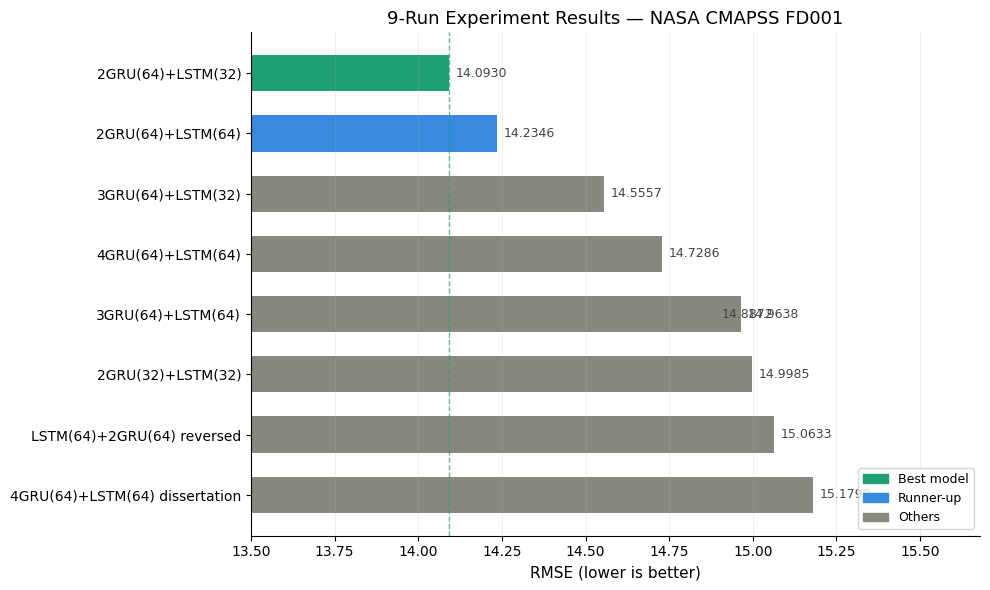


KEY FINDINGS
  best model:       run_02 — 2GRU(64)+LSTM(32)
  best RMSE:        14.0930
  best MAE:         10.1884

  vs dissertation:  run_05 RMSE=15.1790  Δ=1.0859 worse
  vs reversed:      run_09 confirms GRU-first is better than LSTM-first

  takeaway: smaller is better here — 2 GRU layers + small LSTM(32) beats deeper stacks
  chart saved → reports/experiment_comparison.png


In [6]:
# Cell 5 - comparing all 9 runs and picking the best model
# results are already in memory from Cell 4 — just need to visualise and rank them

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df_results = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)

print("=" * 65)
print("EXPERIMENT RESULTS — RANKED BY RMSE")
print("=" * 65)
print(f"\n{'Rank':<5} {'Run':<8} {'Config':<35} {'Drop':<6} {'RMSE':<8} {'MAE':<8}")
print("-" * 65)
for i, row in df_results.iterrows():
    marker = " ← best" if i == 0 else ""
    print(f"  {i+1:<4} {row['run']:<8} {row['config']:<35} {row['dropout']:<6} {row['rmse']:<8.4f} {row['mae']:<8.4f}{marker}")

# ---- bar chart ----
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#1D9E75' if i == 0 else '#378ADD' if i == 1 else '#888780'
          for i in range(len(df_results))]

bars = ax.barh(
    y=df_results['config'],
    width=df_results['rmse'],
    color=colors,
    edgecolor='none',
    height=0.6
)

# add value labels on bars
for bar, rmse in zip(bars, df_results['rmse']):
    ax.text(
        bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
        f'{rmse:.4f}',
        va='center', ha='left', fontsize=9, color='#444'
    )

# reference line at best RMSE
best_rmse = df_results.iloc[0]['rmse']
ax.axvline(x=best_rmse, color='#1D9E75', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel('RMSE (lower is better)', fontsize=11)
ax.set_title('9-Run Experiment Results — NASA CMAPSS FD001', fontsize=13, fontweight='normal')
ax.set_xlim(13.5, df_results['rmse'].max() + 0.5)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3, linewidth=0.5)

legend_patches = [
    mpatches.Patch(color='#1D9E75', label='Best model'),
    mpatches.Patch(color='#378ADD', label='Runner-up'),
    mpatches.Patch(color='#888780', label='Others'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- key findings ----
best = df_results.iloc[0]
worst = df_results.iloc[-1]

print(f"\nKEY FINDINGS")
print(f"  best model:       {best['run']} — {best['config']}")
print(f"  best RMSE:        {best['rmse']:.4f}")
print(f"  best MAE:         {best['mae']:.4f}")
print(f"\n  vs dissertation:  run_05 RMSE={worst['rmse']:.4f}  Δ={worst['rmse']-best['rmse']:.4f} worse")
print(f"  vs reversed:      run_09 confirms GRU-first is better than LSTM-first")
print(f"\n  takeaway: smaller is better here — 2 GRU layers + small LSTM(32) beats deeper stacks")
print(f"  chart saved → reports/experiment_comparison.png")

In [7]:
# Cell 6 - saving the best model
# run_02 won — rebuilding and retraining it cleanly, then saving to models/

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
import pickle
import json
from pathlib import Path

MODELS_DIR = Path('../models')

# ---- rebuild run_02 from scratch with same config ----
# training again cleanly outside MLflow — this becomes the production model

BEST_CONFIG = {
    'run':          'run_02',
    'n_gru_layers': 2,
    'gru_units':    64,
    'lstm_units':   32,
    'dropout_rate': 0.2,
    'l2_reg':       0.001,
    'learning_rate': 0.001,
    'batch_size':   256,
    'epochs':       50,
}

print("rebuilding best model with run_02 config:")
for k, v in BEST_CONFIG.items():
    print(f"  {k}: {v}")

best_model = build_model(
    sequence_length=SEQUENCE_LENGTH,
    n_features=N_FEATURES,
    n_gru_layers=BEST_CONFIG['n_gru_layers'],
    gru_units=BEST_CONFIG['gru_units'],
    lstm_units=BEST_CONFIG['lstm_units'],
    dropout_rate=BEST_CONFIG['dropout_rate'],
    l2_reg=BEST_CONFIG['l2_reg'],
)

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BEST_CONFIG['learning_rate']),
    loss='mse',
    metrics=['mae']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=0
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print("\ntraining run_02 config — best weights auto-saved via checkpoint...")
history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=BEST_CONFIG['epochs'],
    batch_size=BEST_CONFIG['batch_size'],
    callbacks=callbacks,
    verbose=1
)

# ---- evaluate on test set ----
y_pred = best_model.predict(X_test, verbose=0).flatten()
y_pred_capped = np.clip(y_pred, 0, RUL_CAP)
y_test_capped = np.clip(y_test, 0, RUL_CAP)

final_rmse = math.sqrt(mean_squared_error(y_test_capped, y_pred_capped))
final_mae  = mean_absolute_error(y_test_capped, y_pred_capped)
final_r2   = 1 - (np.sum((y_test_capped - y_pred_capped)**2) /
                  np.sum((y_test_capped - np.mean(y_test_capped))**2))

print(f"\n{'='*50}")
print(f"FINAL MODEL PERFORMANCE")
print(f"  RMSE: {final_rmse:.4f}")
print(f"  MAE:  {final_mae:.4f}")
print(f"  R²:   {final_r2:.4f}")
print(f"{'='*50}")

# ---- save predictions for dashboard ----
# saving y_pred now so the API and dashboard don't need to re-run inference on startup
np.save(MODELS_DIR / 'y_pred_test.npy', y_pred_capped)

# ---- save best model config with final metrics ----
best_model_config = {
    'architecture': {
        'n_gru_layers':  BEST_CONFIG['n_gru_layers'],
        'gru_units':     BEST_CONFIG['gru_units'],
        'lstm_units':    BEST_CONFIG['lstm_units'],
        'dropout_rate':  BEST_CONFIG['dropout_rate'],
        'l2_reg':        BEST_CONFIG['l2_reg'],
    },
    'training': {
        'learning_rate': BEST_CONFIG['learning_rate'],
        'batch_size':    BEST_CONFIG['batch_size'],
        'best_epoch':    len(history.history['loss']),
    },
    'performance': {
        'test_rmse': round(final_rmse, 4),
        'test_mae':  round(final_mae, 4),
        'test_r2':   round(final_r2, 4),
    },
    'data': {
        'feature_cols':    config['feature_cols'],
        'sequence_length': SEQUENCE_LENGTH,
        'n_features':      N_FEATURES,
        'rul_cap':         RUL_CAP,
        'sensors_dropped': config['sensors_dropped'],
    }
}

with open(MODELS_DIR / 'best_model_config.json', 'w') as f:
    json.dump(best_model_config, f, indent=2)

print(f"\nsaved:")
print(f"  models/best_model.keras        — production model weights")
print(f"  models/best_model_config.json  — architecture + metrics")
print(f"  models/y_pred_test.npy         — precomputed fleet predictions")
print(f"  models/scaler.pkl              — already saved in preprocessing")
print(f"  models/model_config.pkl        — already saved in preprocessing")

rebuilding best model with run_02 config:
  run: run_02
  n_gru_layers: 2
  gru_units: 64
  lstm_units: 32
  dropout_rate: 0.2
  l2_reg: 0.001
  learning_rate: 0.001
  batch_size: 256
  epochs: 50

training run_02 config — best weights auto-saved via checkpoint...
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 7059.2422 - mae: 73.6015 - val_loss: 6791.3359 - val_mae: 71.8281 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 5236.9150 - mae: 61.6659 - val_loss: 4450.1357 - val_mae: 57.0192 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 2922.7629 - mae: 43.8119 - val_loss: 1965.4993 - val_mae: 36.7849 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 1215.6317 - mae: 27.5406 - val_loss: 665.0915 - val_mae: 21.8947 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 521.7742 - mae: 17.8933 - val_loss: 312.7942 - val_mae: 15.0928 - learning_rate: 

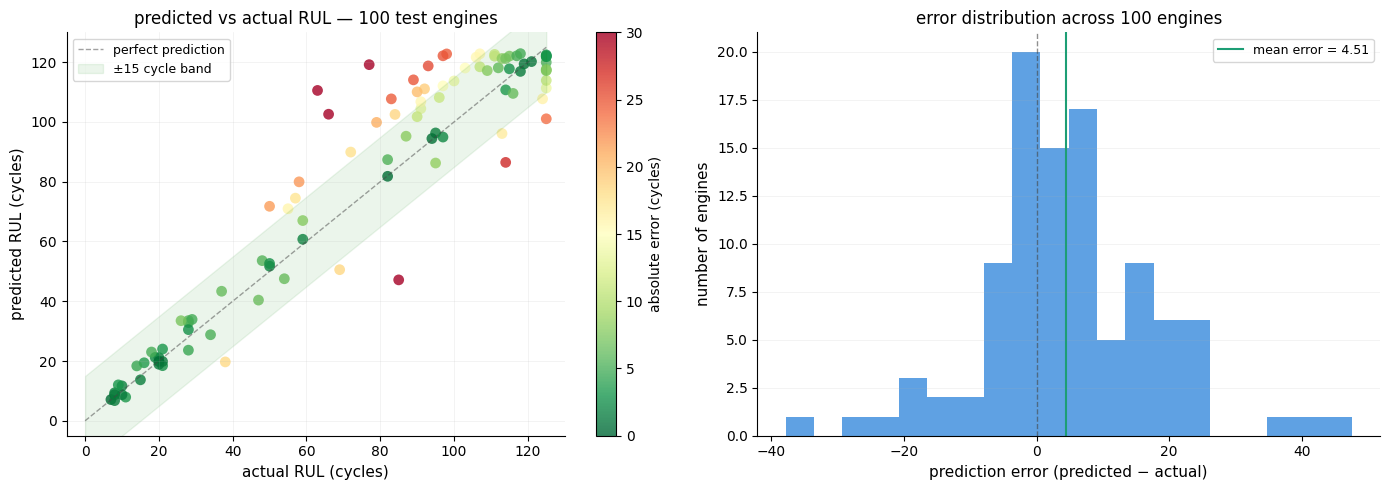

ENGINE-LEVEL BREAKDOWN
  total engines:          100
  within ±15 cycles:      71  (71%)
  within ±30 cycles:      96  (96%)

  over-predictions:       64  (predicted MORE life than actual — risky)
  under-predictions:      36  (predicted LESS life — conservative)

  mean error:             4.51 cycles
  std of errors:          13.32 cycles

  worst over-prediction:  engine 79  error=47.6 cycles
  worst under-prediction: engine 93  error=-37.8 cycles

chart saved → reports/predicted_vs_actual.png


In [8]:
# Cell 7 - predicted vs actual RUL — visualising how well the model does per engine

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

y_pred_capped = np.load('../models/y_pred_test.npy')
y_test_capped = np.clip(y_test, 0, RUL_CAP)

errors = y_pred_capped - y_test_capped
abs_errors = np.abs(errors)

# ---- scatter plot — predicted vs actual ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# colour by absolute error — makes outliers immediately obvious
norm = mcolors.Normalize(vmin=0, vmax=30)
cmap = plt.cm.RdYlGn_r

ax = axes[0]
sc = ax.scatter(
    y_test_capped, y_pred_capped,
    c=abs_errors, cmap=cmap, norm=norm,
    alpha=0.8, s=60, edgecolors='none'
)
# perfect prediction line
ax.plot([0, RUL_CAP], [0, RUL_CAP], color='#444', linewidth=1,
        linestyle='--', alpha=0.5, label='perfect prediction')

# ±15 cycle tolerance bands — within 15 cycles is acceptable in practice
ax.fill_between([0, RUL_CAP], [-15, RUL_CAP-15], [15, RUL_CAP+15],
                alpha=0.08, color='green', label='±15 cycle band')

ax.set_xlabel('actual RUL (cycles)', fontsize=11)
ax.set_ylabel('predicted RUL (cycles)', fontsize=11)
ax.set_title('predicted vs actual RUL — 100 test engines', fontsize=12, fontweight='normal')
ax.set_xlim(-5, RUL_CAP + 5)
ax.set_ylim(-5, RUL_CAP + 5)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.2, linewidth=0.5)

plt.colorbar(sc, ax=ax, label='absolute error (cycles)')

# ---- error distribution ----
ax2 = axes[1]
ax2.hist(errors, bins=20, color='#378ADD', edgecolor='none', alpha=0.8)
ax2.axvline(x=0, color='#444', linewidth=1, linestyle='--', alpha=0.6)
ax2.axvline(x=errors.mean(), color='#1D9E75', linewidth=1.5,
            linestyle='-', label=f'mean error = {errors.mean():.2f}')

ax2.set_xlabel('prediction error (predicted − actual)', fontsize=11)
ax2.set_ylabel('number of engines', fontsize=11)
ax2.set_title('error distribution across 100 engines', fontsize=12, fontweight='normal')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.2, linewidth=0.5)

plt.tight_layout()
plt.savefig('../reports/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- engine-level breakdown ----
within_15  = np.sum(abs_errors <= 15)
within_30  = np.sum(abs_errors <= 30)
over_pred  = np.sum(errors > 0)   # predicted more life than actual — dangerous
under_pred = np.sum(errors < 0)   # predicted less life — conservative, safer

print("=" * 50)
print("ENGINE-LEVEL BREAKDOWN")
print("=" * 50)
print(f"  total engines:          100")
print(f"  within ±15 cycles:      {within_15}  ({within_15}%)")
print(f"  within ±30 cycles:      {within_30}  ({within_30}%)")
print(f"\n  over-predictions:       {over_pred}  (predicted MORE life than actual — risky)")
print(f"  under-predictions:      {under_pred}  (predicted LESS life — conservative)")
print(f"\n  mean error:             {errors.mean():.2f} cycles")
print(f"  std of errors:          {errors.std():.2f} cycles")
print(f"\n  worst over-prediction:  engine {np.argmax(errors)+1}  error={errors.max():.1f} cycles")
print(f"  worst under-prediction: engine {np.argmin(errors)+1}  error={errors.min():.1f} cycles")
print(f"\nchart saved → reports/predicted_vs_actual.png")

In [10]:
# Cell 8 - generating SHAP background data for the API
# SHAP needs a small set of background samples to compute expected values
# doing this once here and saving — so the API loads it instantly, no recomputation

import shap
import numpy as np
import pickle
from pathlib import Path

MODELS_DIR = Path('../models')

# ---- generate background samples ----
# using 100 random training samples as the SHAP background
# more samples = more accurate but slower API — 100 is the sweet spot
np.random.seed(42)
background_idx = np.random.choice(len(X_train), size=100, replace=False)
shap_background = X_train[background_idx]

print(f"background samples shape: {shap_background.shape}")
print(f"  → (100 samples, {SEQUENCE_LENGTH} timesteps, {N_FEATURES} features)")

# ---- build the SHAP explainer ----
# using GradientExplainer — works well with TF/Keras sequential models
# same approach used in the sepsis project
explainer = shap.GradientExplainer(best_model, shap_background)

print("\nSHAP GradientExplainer built successfully")

# ---- test on a few engines to make sure it works ----
print("\ntesting SHAP on 5 engines...")
test_shap_values = explainer.shap_values(X_test[:5])

# squeezing trailing output dim — GradientExplainer returns (5, 30, 14, 1)
# the 1 is from the single output neuron, need (5, 30, 14)
test_shap_values = np.array(test_shap_values).squeeze(-1)
test_shap_mean = np.abs(test_shap_values).mean(axis=1)  # → (5, 14)

print(f"  shap_values shape:      {test_shap_values.shape}")
print(f"  mean importance shape:  {test_shap_mean.shape}")

# ---- show feature importance for engine 1 ----
feature_cols = config['feature_cols']
engine1_importance = test_shap_mean[0]
ranked = sorted(zip(feature_cols, engine1_importance), key=lambda x: x[1], reverse=True)

print("\nSHAP feature importance — engine 1 (example):")
print(f"  {'sensor':<8} {'mean |shap|':>12}")
print(f"  {'-'*22}")
for feat, val in ranked:
    bar = '█' * int(float(val) * 200)
    print(f"  {feat:<8} {float(val):>12.4f}  {bar}")

# ---- save everything the API needs ----
np.save(MODELS_DIR / 'shap_background.npy', shap_background)

with open(MODELS_DIR / 'feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print(f"\nsaved:")
print(f"  models/shap_background.npy  — {shap_background.shape} background samples")
print(f"  models/feature_cols.pkl     — {len(feature_cols)} feature names")
print(f"\nPhase 3 complete — all model files ready for Phase 4 (FastAPI)")
print(f"\nmodels/ directory now contains:")
for f in sorted(MODELS_DIR.iterdir()):
    print(f"  {f.name}")

background samples shape: (100, 30, 14)
  → (100 samples, 30 timesteps, 14 features)

SHAP GradientExplainer built successfully

testing SHAP on 5 engines...
  shap_values shape:      (5, 30, 14)
  mean importance shape:  (5, 14)

SHAP feature importance — engine 1 (example):
  sensor    mean |shap|
  ----------------------
  s_11           1.1432  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  s_12           0.8394  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  s_20           0.7462  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  s_9            0.7101  ███████████████████████████